<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/ProgrammingDay01/slide-001.png" class="img-responsive"/>
</div>

device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


train subset size: 1024


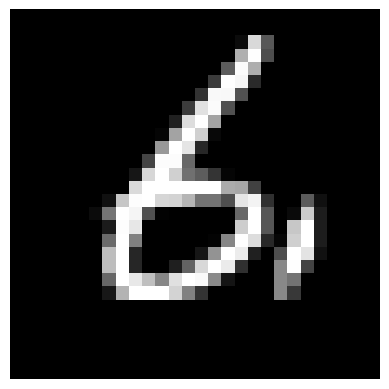

tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], device='cuda:0')


In [ ]:
# @title Load Dataset and Pick Example Image

import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -----------------------------
# 1) Data (RANDOM subset)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# ----- KEY PART: RANDOM SUBSET -----
N_TRAIN = 1024  # size of subset

# make it reproducible for teaching (change/remove seed if you want new samples)
random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

all_indices = list(range(len(train_full)))
random.shuffle(all_indices)
subset_indices = all_indices[:N_TRAIN]

train_ds = Subset(train_full, subset_indices)

# -----------------------------------

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

example_img = train_ds[0][0].to(device)
example_expected = torch.nn.functional.one_hot(torch.tensor(train_ds[0][1]), num_classes=10).float().unsqueeze(0).to(device)

print("train subset size:", len(train_ds))

plt.figure()
plt.imshow(example_img.cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

print(example_expected)

In [ ]:
W = (0.01 * torch.randn(784, 10, device=device)).requires_grad_(True)
b = torch.zeros(10, device=device, requires_grad=True)

def forward(input_vector):
    return input_vector @ W + b

In [ ]:
print('Example Image Shape:', example_img.shape)

input_vector = example_img.view(example_img.size(0), -1)
print('Input Vector Shape:', input_vector.shape)

print('Sample Image Prediction:')
example_prediction_probs = torch.nn.functional.softmax(forward(input_vector), dim=1).tolist()[0]
print(f'\tOutput Vector for sample image:', [f'{x:.4f}' for x in example_prediction_probs])
print(f'\tGround Truth Vector for sample image:  ', [f'{x:.4f}' for x in example_expected[0].tolist()])
print('\t', '-' * 80)
print(f'\tPredicted:', f'{torch.argmax(torch.tensor(example_prediction_probs))}')
print(f'\tActual:  ', f'{torch.argmax(example_expected[0])}')

Example Image Shape: torch.Size([1, 28, 28])
Input Vector Shape: torch.Size([1, 784])
Sample Image Prediction:
	Output Vector for sample image: ['0.0829', '0.1536', '0.1364', '0.1385', '0.0744', '0.1148', '0.0488', '0.0964', '0.0703', '0.0839']
	Ground Truth Vector for sample image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	 --------------------------------------------------------------------------------
	Predicted: 1
	Actual:   6


In [ ]:
linear_layer = torch.nn.Linear(784, 10, device=device)

example_prediction_probs = torch.nn.functional.softmax(linear_layer(input_vector), dim=1).tolist()[0]

print(f'\tOutput Vector for sample image:', [f'{x:.4f}' for x in example_prediction_probs])
print(f'\tGround Truth Vector for sample image:  ', [f'{x:.4f}' for x in example_expected[0].tolist()])
print('\t', '-' * 80)
print(f'\tPredicted:', f'{torch.argmax(torch.tensor(example_prediction_probs))}')
print(f'\tActual:  ', f'{torch.argmax(example_expected[0])}')

	Output Vector for sample image: ['0.0491', '0.1363', '0.0549', '0.0951', '0.0530', '0.1328', '0.1895', '0.1563', '0.0676', '0.0655']
	Ground Truth Vector for sample image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	 --------------------------------------------------------------------------------
	Predicted: 6
	Actual:   6


In [ ]:
example_loss = F.cross_entropy(forward(example_img), example_expected).tolist()
print(f'\tLoss for sample image:', round(example_loss, 4))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (28x28 and 784x10)